In [2]:
import numpy as np 
import pandas as pd

In [ ]:
class LinearRegression:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for i in range(self.n_iterations):
            y_pred =  np.dot(X,self.weights) + self.bias
            dw = 1/n_samples *(np.dot(X.T, y_pred - y))
            db = 1/n_samples *(np.sum(y_pred - y))

            self.weights = self.weights - self.learning_rate*dw
            self.bias = self.bias - self.learning_rate*db
            
    
    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

In [15]:
X = np.arange(1, 1001).reshape(-1, 1)
y = np.arange(2, 2002, 2)

In [16]:
model = LinearRegression(learning_rate=0.000001, n_iterations=1000)
model.fit(X,y)

In [21]:
X_test = np.array([[1001]])
y_pred = model.predict(X_test)

print(y_pred)

[2001.99849888]


## L2 Regularization

- To prevent overfitting, L2 regularization is applied to the weights.
- Error function is calculated like this:
- 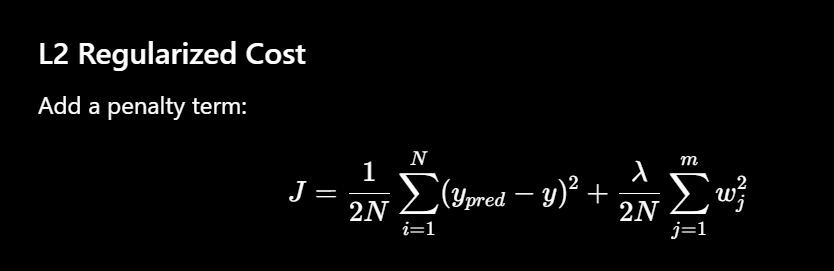

In [22]:
### Linear Regression with L2 Regularization
class LinearRegression:
    def __init__(self, learning_rate=0.01, n_iterations=1000, lambda_l2 = 0.01):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.lambda_l2 = lambda_l2
    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for i in range(self.n_iterations):
            y_pred =  np.dot(X,self.weights) + self.bias
            dw = 1/n_samples *(np.dot(X.T, y_pred - y)) + 1/n_samples * (self.lambda_l2) * self.weights
            db = 1/n_samples *(np.sum(y_pred - y))

            self.weights = self.weights - self.learning_rate*dw
            self.bias = self.bias - self.learning_rate*db
            
    
    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

In [23]:
X = np.arange(1, 1001).reshape(-1, 1)
y = np.arange(2, 2002, 2)
model = LinearRegression(learning_rate=0.000001, n_iterations=1000)
model.fit(X,y)

X_test = np.array([[1001]])
y_pred = model.predict(X_test)

print(y_pred)

[2001.99849882]


## KNN

- Look at k nearest neigbours
- Take majority vote  

In [1]:
def KNearestNeighbour(X,Y, queryPoint, k):
    n = len(X)
    distances = []
    for i in range(n):
        d = np.sqrt(np.sum((X[i] - queryPoint)**2,axis=1))
        distances.append([d,Y[i]])
    
    distances = sorted(distances , key= lambda x: x[0])
    count = {}
    for i in range(k):
        label = distances[i][1]
        # get majority y[i]
        if label in count:
            count[label] += 1
        else:
            count[label] = 1
    return max(count, key=count.get)

In [14]:
class KNearestNeighbors:
    def __init__(self, k=3):
        self.k = k
    
    def fit(self,X, y):
        self.X_train = np.array(X)
        self.y_train = np.array(y)
    # KNN is a lazy learner

    def predict(self, X_test):
        X_test = np.array(X_test)
        predictions = []
        if X_test.ndim == 1:
            X_test = X_test.reshape(1, -1)
        for x in X_test:
            predict = self.predict_single_point(x)
            predictions.append(predict)
        return np.array(predictions)
    
    def predict_single_point(self, query_point):
        n = len(self.X_train)
        X = self.X_train
        Y = self.y_train
        distances = []
        for i in range(n):
            d = np.sqrt(np.sum((X[i] - query_point)**2))
            distances.append((d, Y[i])) 
        
        distances = sorted(distances, key = lambda x: x[0])
        count = {}
        for i in range(self.k):
            label = distances[i][1]
            if label in count:
                count[label] += 1
            else:
                count[label] = 1
        
        return max(count , key= count.get)

In [8]:
import numpy as np

X_train = [
    [1, 1],
    [2, 2],
    [3, 3],
    [6, 6],
    [7, 7]
]

y_train = [
    0,
    0,
    0,
    1,
    1
]

knn = KNearestNeighbors(k=3)
knn.fit(X_train, y_train)

print(knn.predict([[-8.5, 2.5]]))

[0]


Model treats all $k$ neighbors equally.

Imagine $k=3$.

Neighbor 1 is 0.01 units away (Extremely close) $\rightarrow$ Class A.

Neighbor 2 is 5.0 units away (Far) $\rightarrow$ Class B.

Neighbor 3 is 5.1 units away (Far) $\rightarrow$ Class B.Your current code will vote Class B (2 votes vs 1).

However, logic dictates it should probably be Class A because that neighbor is right on top of the query point.Question: How would you modify your predict function to implement Distance-Weighted KNN (Inverse Distance Weighting)?"

In [11]:
#Weighted KNN
class KNearestNeighborsWeighted:
    def __init__(self, k=3):
        self.k = k
    
    def fit(self,X, y):
        self.X_train = np.array(X)
        self.y_train = np.array(y)
    # KNN is a lazy learner

    def predict(self, X_test):
        X_test = np.array(X_test)
        predictions = []
        if X_test.ndim == 1:
            X_test = X_test.reshape(1, -1)
        for x in X_test:
            predict = self.predict_single_point(x)
            predictions.append(predict)
        return np.array(predictions)
    
    def predict_single_point(self, query_point):
        n = len(self.X_train)
        X = self.X_train
        Y = self.y_train
        distances = []
        for i in range(n):
            d = np.sqrt(np.sum((X[i] - query_point)**2))
            distances.append((d, Y[i])) 
        
        distances = sorted(distances, key = lambda x: x[0])
        count = {}
        class_scores = {}
        epsilon = 1e-5
        for i in range(self.k):
            label = distances[i][1]
            dist = distances[i][0]
            weight = 1/(dist + epsilon)
            if label in count:
                class_scores[label] += weight
            else:
                class_scores[label] = weight
        
        return max(class_scores , key= class_scores.get)

In [16]:
X_train = [[0, 0], [5, 5], [5, 6]]
y_train = [0, 1, 1]

model = KNearestNeighborsWeighted(k=3)
model.fit(X_train, y_train)
query = [[0.1, 0.1]]
print(f"Prediction: {model.predict(query)}") # Expected: [0]

Prediction: [0]
